### Import Libraries

In [1]:
import pandas as pd
import nltk
import string
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

### Download NLTK Data

In [2]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Janu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### Load Dataset

In [3]:
train_df = pd.read_csv("train.txt", sep=';', names=['text', 'emotion'])
test_df = pd.read_csv("test.txt", sep=';', names=['text', 'emotion'])
val_df = pd.read_csv("val.txt", sep=';', names=['text', 'emotion'])

train_df.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


### Check Dataset Info

In [4]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Validation shape:", val_df.shape)

train_df['emotion'].value_counts()

Train shape: (16000, 2)
Test shape: (2000, 2)
Validation shape: (2000, 2)


emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

### Text Cleaning Function

In [5]:
def clean_text(text):
    text = text.lower()
    text = "".join([char for char in text if char not in string.punctuation])
    words = text.split()
    words = [word for word in words if word not in stopwords.words('english')]
    return " ".join(words)

### Apply Cleaning

In [6]:
train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text'] = test_df['text'].apply(clean_text)

train_df.head()

,text,emotion,clean_text
0,i didnt feel humiliated,sadness,didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,sadness,go feeling hopeless damned hopeful around some...
2,im grabbing a minute to post i feel greedy wrong,anger,im grabbing minute post feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,love,ever feeling nostalgic fireplace know still pr...
4,i am feeling grouchy,anger,feeling grouchy


### Feature Extraction

In [7]:
vectorizer = TfidfVectorizer()

X_train = vectorizer.fit_transform(train_df['clean_text'])
X_test = vectorizer.transform(test_df['clean_text'])

y_train = train_df['emotion']
y_test = test_df['emotion']

### Train Model

In [8]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

### Evaluate Model

In [9]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.865

Classification Report:

              precision    recall  f1-score   support

       anger       0.88      0.83      0.86       275
        fear       0.87      0.79      0.83       224
         joy       0.84      0.95      0.89       695
        love       0.79      0.60      0.69       159
     sadness       0.89      0.92      0.91       581
    surprise       0.89      0.50      0.64        66

    accuracy                           0.86      2000
   macro avg       0.86      0.77      0.80      2000
weighted avg       0.86      0.86      0.86      2000



### Prediction Function

In [10]:
def predict_emotion(text):
    cleaned = clean_text(text)
    vector = vectorizer.transform([cleaned])
    prediction = model.predict(vector)
    return prediction[0]

### Test with Custom Input

In [11]:
predict_emotion("I feel very happy today")

'joy'

In [12]:
predict_emotion("I am scared of exams")

'fear'

In [13]:
predict_emotion("I am very angry")

'anger'

### Emotion Distribution

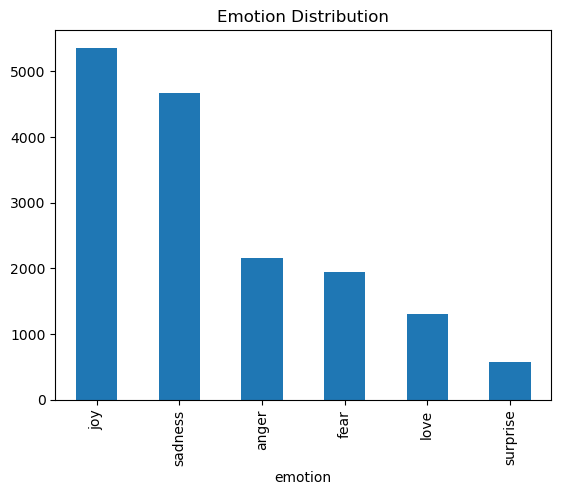

In [14]:
import matplotlib.pyplot as plt

train_df['emotion'].value_counts().plot(kind='bar')
plt.title("Emotion Distribution")
plt.show()